In [ ]:
pip install opencv-python numpy pandas matplotlib

In [ ]:
pip install kagglehub

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset folder: /kaggle/input/skin-cancer-mnist-ham10000
       image_id  dx   age     sex     localization
0  ISIC_0027539  nv  40.0  female          abdomen
1  ISIC_0031493  nv  60.0  female             back
2  ISIC_0028462  nv  45.0  female            trunk
3  ISIC_0029992  nv  50.0    male            trunk
4  ISIC_0025739  nv  35.0  female  lower extremity


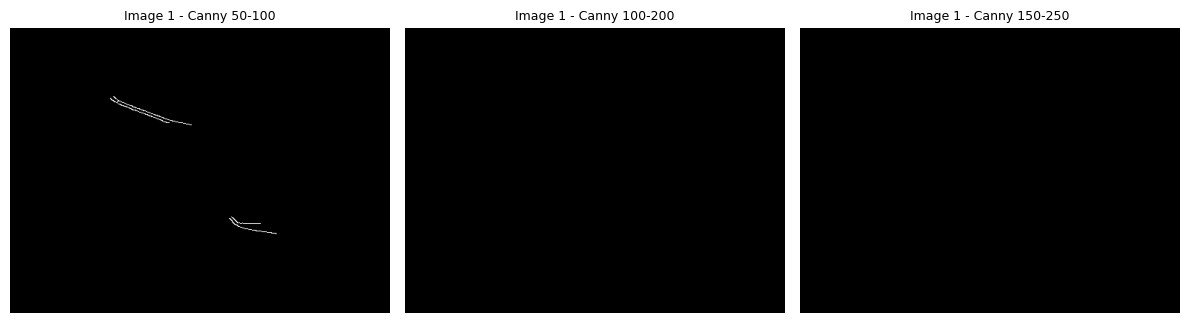

Image 1: scores = {(50, 100): 0.0, (100, 200): 0.0, (150, 250): 0.0} -> best = (50, 100)


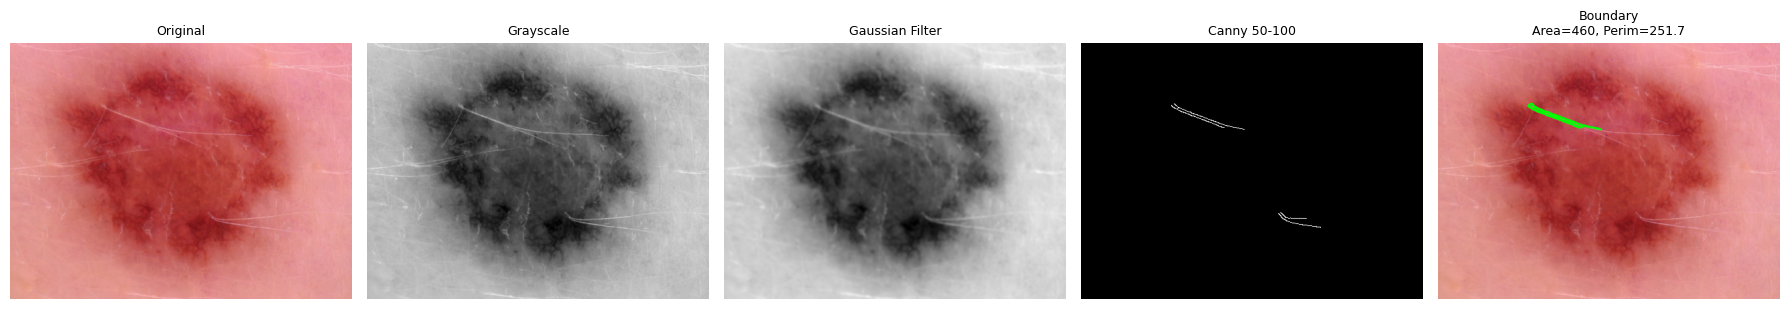

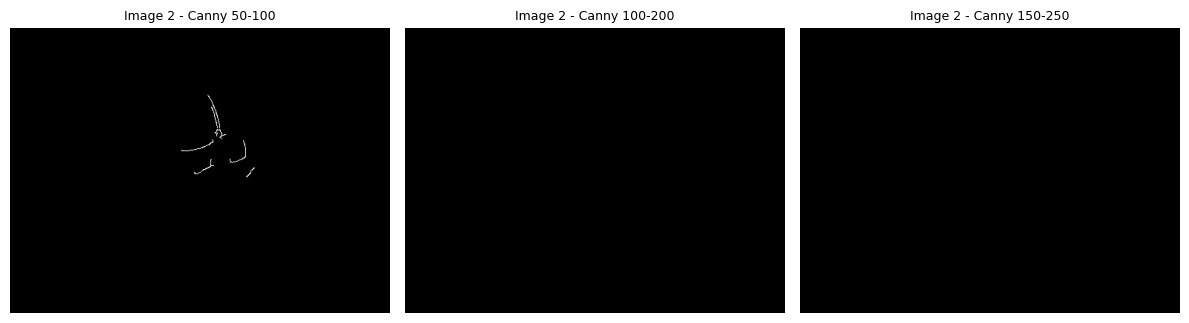

Image 2: scores = {(50, 100): 0.0, (100, 200): 0.0, (150, 250): 0.0} -> best = (50, 100)


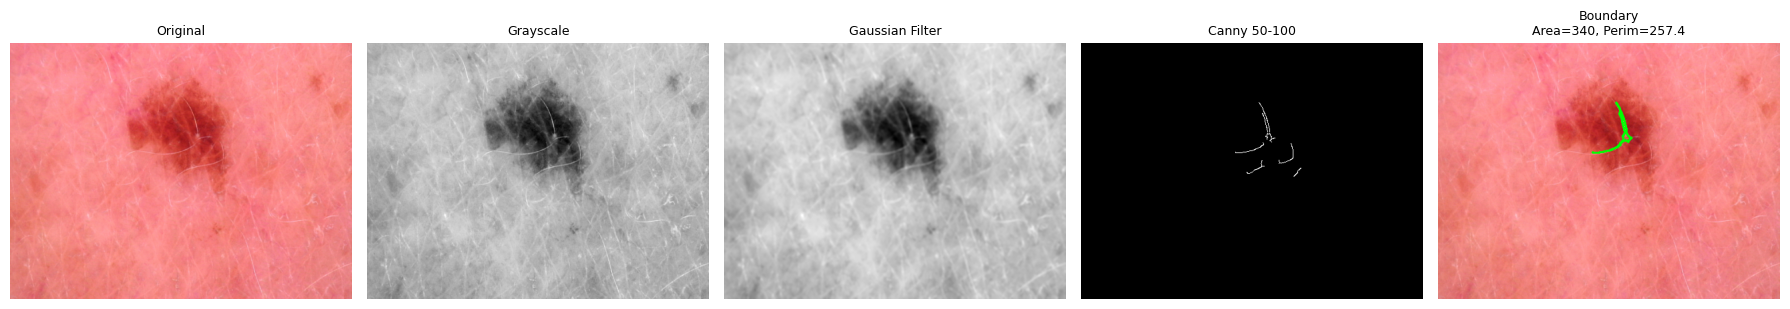

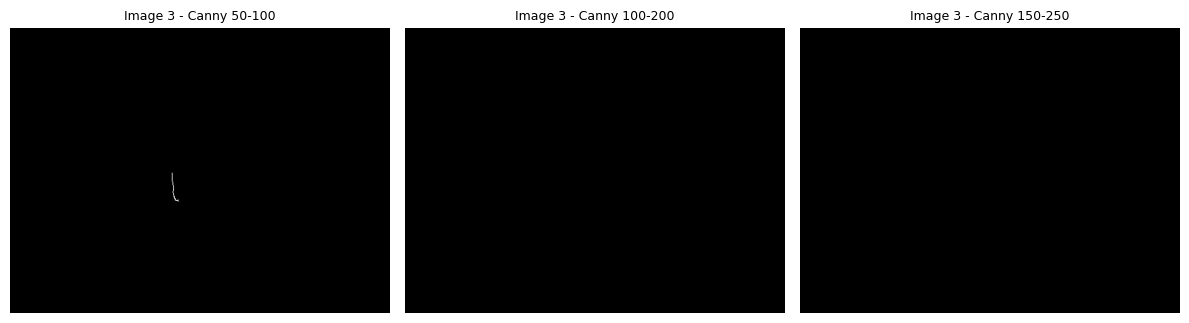

Image 3: scores = {(50, 100): 0.0, (100, 200): 0.0, (150, 250): 0.0} -> best = (50, 100)


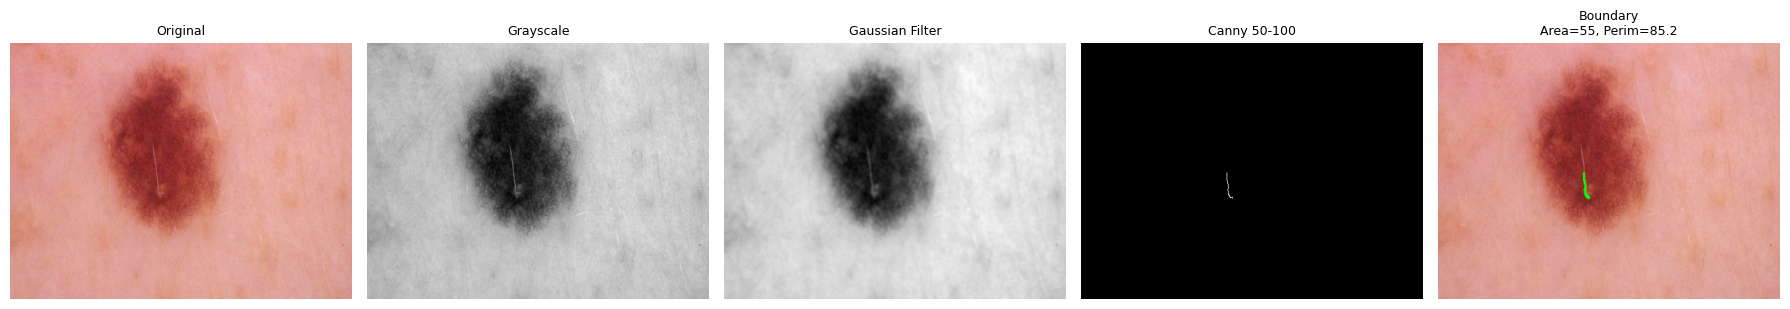

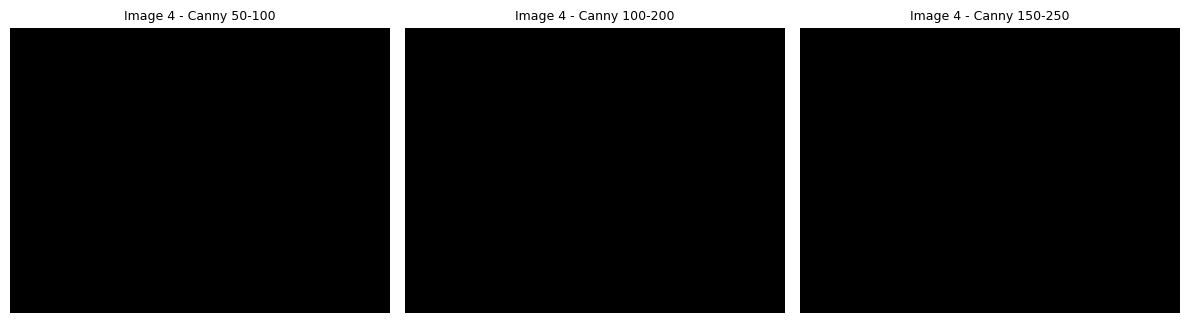

Image 4: scores = {(50, 100): 0.0, (100, 200): 0.0, (150, 250): 0.0} -> best = (50, 100)


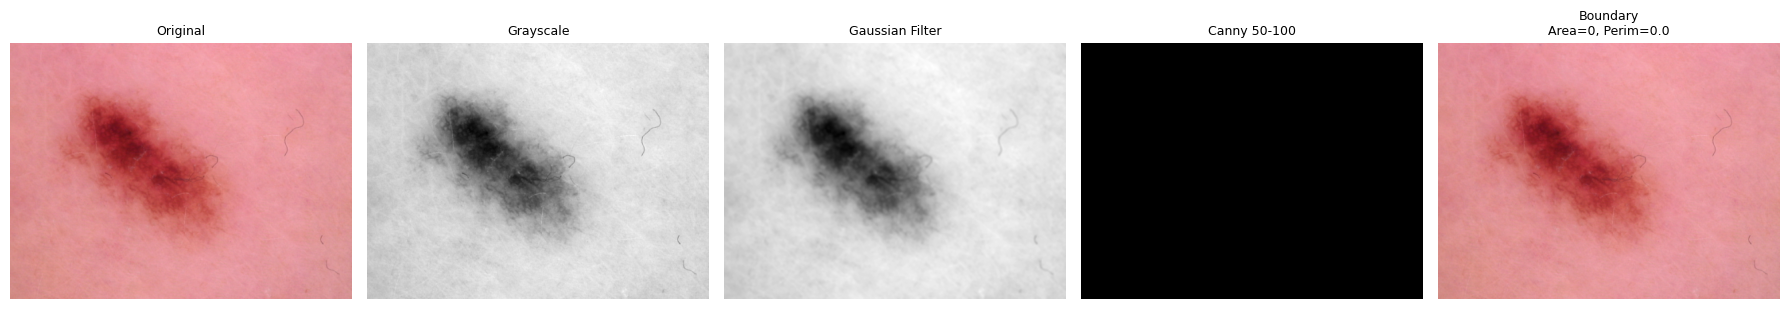

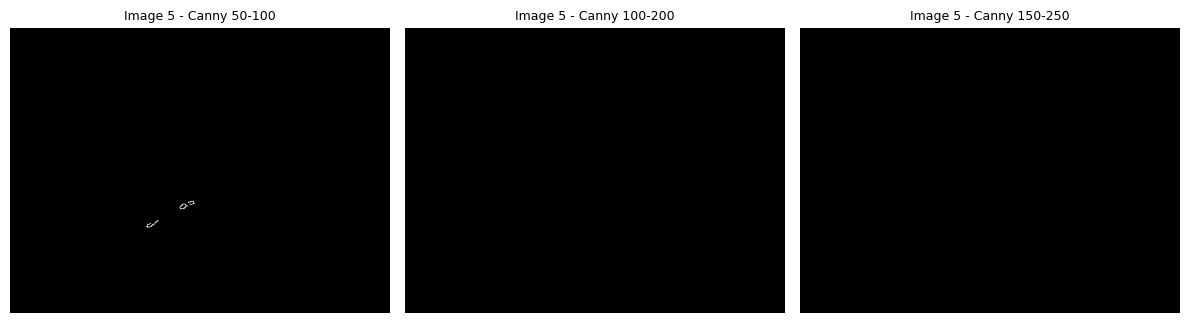

Image 5: scores = {(50, 100): 0.0, (100, 200): 0.0, (150, 250): 0.0} -> best = (50, 100)


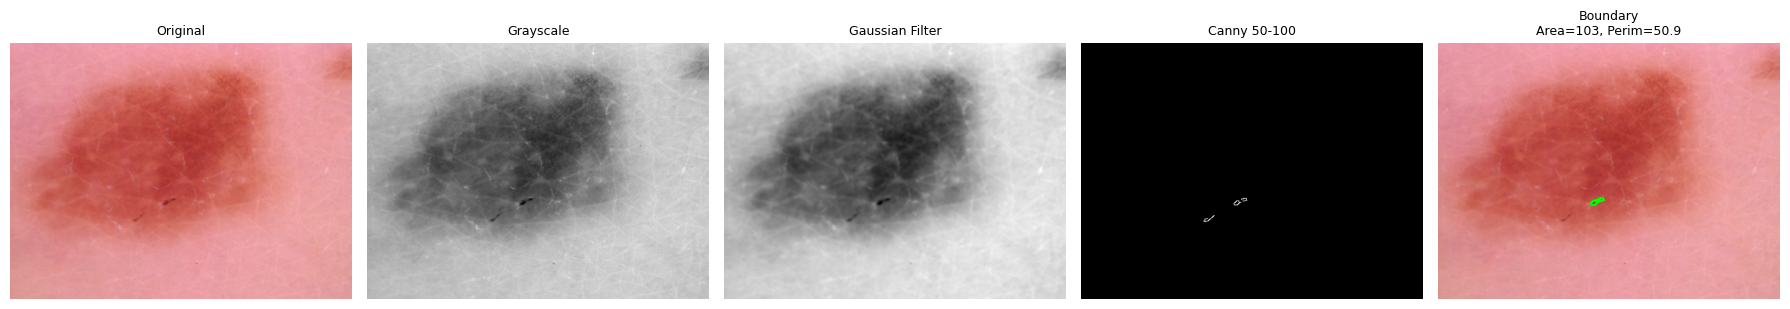


=== Results Table ===
  Image             Best Filter    Edge Method  Area (pixels)  Perimeter (pixels)
Image 1 Gaussian 5x5, sigma=1.4 Canny (50-100)            460               251.7
Image 2 Gaussian 5x5, sigma=1.4 Canny (50-100)            340               257.4
Image 3 Gaussian 5x5, sigma=1.4 Canny (50-100)             55                85.2
Image 4 Gaussian 5x5, sigma=1.4 Canny (50-100)              0                 0.0
Image 5 Gaussian 5x5, sigma=1.4 Canny (50-100)            103                50.9

=== Numeric metrics ===
          Method  Noise (fragments, lower=better)  Edge Quality (continuity)  Boundary (Dice)  Overall Score
Original + Sobel                           2729.8                      0.377            0.424          0.283
Original + Canny                              2.2                      0.517            0.014          0.460
 Average + Sobel                            601.4                      0.639            0.694          0.703
 Average + Canny        

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Settings ----------------
import os, glob
import kagglehub
import pandas as pd

# ---------------- HAM10000: automatic download + image selection ----------------
N_IMAGES = 5
SEED = 42
DX_TO_USE = ["mel", "nv", "bkl"]   # melanoma, melanocytic nevus, benign keratosis

def get_ham10000_paths(n=N_IMAGES, seed=SEED, dx_list=DX_TO_USE):
    # Downloads once, then reuses the local cache on later runs
    root = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print("Dataset folder:", root)

    meta = pd.read_csv(os.path.join(root, "HAM10000_metadata.csv"))

    # Map image_id -> full path (the images are split across two folders)
    all_jpgs = glob.glob(os.path.join(root, "**", "*.jpg"), recursive=True)
    id_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in all_jpgs}

    meta = meta[meta["dx"].isin(dx_list) & meta["image_id"].isin(id_to_path)]
    sample = meta.sample(n=n, random_state=seed).reset_index(drop=True)

    print(sample[["image_id", "dx", "age", "sex", "localization"]])
    return [id_to_path[i] for i in sample["image_id"]]

IMAGE_PATHS = get_ham10000_paths()
THRESHOLDS = [(50, 100), (100, 200), (150, 250)]
GAUSS_KSIZE, GAUSS_SIGMA = (5, 5), 1.4
MAX_SIDE = 512
COMPARE_CANNY = (100, 200)  # thresholds used in the final comparison table


# ---------------- Helpers ----------------
def load_image(path):
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(path)
    scale = MAX_SIDE / max(bgr.shape[:2])
    if scale < 1:
        bgr = cv2.resize(bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return bgr


def show(ax, img, title):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def sobel_edges(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.convertScaleAbs(np.hypot(gx, gy))
    _, edges = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return edges


def lesion_from_edges(edges):
    """Morphological closing + external contour -> largest contour = lesion."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # ignore a contour that is just the image frame
    limit = 0.95 * edges.shape[0] * edges.shape[1]
    contours = [c for c in contours if cv2.contourArea(c) < limit]
    if not contours:
        return None, np.zeros_like(edges), 0, 0.0
    c = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(edges)
    cv2.drawContours(mask, [c], -1, 255, thickness=-1)   # filled lesion
    area = cv2.countNonZero(mask)                         # pixels inside boundary
    perimeter = cv2.arcLength(c, True)                    # boundary length
    return c, mask, area, perimeter


def score_edges(edges):
    """Heuristic for Task 4: plausible size + smooth/compact contour + little clutter."""
    c, mask, area, _ = lesion_from_edges(edges)
    if c is None:
        return 0.0
    frac = area / edges.size
    if not 0.02 < frac < 0.85:
        return 0.0
    hull = cv2.contourArea(cv2.convexHull(c))
    solidity = cv2.contourArea(c) / hull if hull > 0 else 0
    clutter = np.count_nonzero(edges) / edges.size
    return solidity * (1 - clutter)


def reference_mask(blur):
    """Otsu-based pseudo ground truth (lesion is darker than skin)."""
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    cs, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = np.zeros_like(m)
    if cs:
        cv2.drawContours(out, [max(cs, key=cv2.contourArea)], -1, 255, -1)
    return out


def dice(a, b):
    a, b = a > 0, b > 0
    s = a.sum() + b.sum()
    return 2 * np.logical_and(a, b).sum() / s if s else 0.0


def edge_metrics(edges):
    n, _, stats, _ = cv2.connectedComponentsWithStats(edges, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    if len(areas) == 0:
        return 0, 0.0
    fragments = int((areas < 30).sum())                 # isolated noisy bits
    continuity = areas.max() / areas.sum()              # how connected the edges are
    return fragments, continuity


# ---------------- Main pipeline (Tasks 1-6) ----------------
results = []
store = []  # keep images for the final comparison

for idx, path in enumerate(IMAGE_PATHS, start=1):
    # Task 1: load
    original = load_image(path)

    # Task 2: grayscale + Gaussian
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    gauss = cv2.GaussianBlur(gray, GAUSS_KSIZE, GAUSS_SIGMA)

    # Task 3: Canny with three thresholds
    edge_maps = {t: cv2.Canny(gauss, *t) for t in THRESHOLDS}
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (t, e) in zip(axs, edge_maps.items()):
        show(ax, e, f"Image {idx} - Canny {t[0]}-{t[1]}")
    plt.tight_layout()
    plt.show()

    # Task 4: choose best threshold (check visually too!)
    scores = {t: score_edges(e) for t, e in edge_maps.items()}
    best_t = max(scores, key=scores.get)
    best_edges = edge_maps[best_t]
    print(f"Image {idx}: scores = {scores} -> best = {best_t}")

    # Task 5: boundary
    contour, mask, area, perimeter = lesion_from_edges(best_edges)
    boundary_img = original.copy()
    if contour is not None:
        cv2.drawContours(boundary_img, [contour], -1, (0, 255, 0), 2)

    # Required visualization
    fig, axs = plt.subplots(1, 5, figsize=(18, 4))
    show(axs[0], original, "Original")
    show(axs[1], gray, "Grayscale")
    show(axs[2], gauss, "Gaussian Filter")
    show(axs[3], best_edges, f"Canny {best_t[0]}-{best_t[1]}")
    show(axs[4], boundary_img, f"Boundary\nArea={area}, Perim={perimeter:.1f}")
    plt.tight_layout()
    plt.savefig(f"result_image{idx}.png", dpi=150)
    plt.show()

    # Task 6: area and perimeter
    results.append({
        "Image": f"Image {idx}",
        "Best Filter": f"Gaussian {GAUSS_KSIZE[0]}x{GAUSS_KSIZE[1]}, sigma={GAUSS_SIGMA}",
        "Edge Method": f"Canny ({best_t[0]}-{best_t[1]})",
        "Area (pixels)": int(area),
        "Perimeter (pixels)": round(perimeter, 1),
    })
    store.append((gray, gauss))

df_results = pd.DataFrame(results)
print("\n=== Results Table ===")
print(df_results.to_string(index=False))
df_results.to_csv("results_table.csv", index=False)


# ---------------- Final Comparison (8 methods) ----------------
def get_filters(gray):
    return {
        "Original": gray,
        "Average": cv2.blur(gray, (5, 5)),
        "Gaussian": cv2.GaussianBlur(gray, GAUSS_KSIZE, GAUSS_SIGMA),
        "Median": cv2.medianBlur(gray, 5),
    }

rows = {}
for gray, gauss in store:
    ref = reference_mask(gauss)
    for fname, fimg in get_filters(gray).items():
        for ename in ["Sobel", "Canny"]:
            edges = sobel_edges(fimg) if ename == "Sobel" else cv2.Canny(fimg, *COMPARE_CANNY)
            frag, cont = edge_metrics(edges)
            _, mask, _, _ = lesion_from_edges(edges)
            rows.setdefault(f"{fname} + {ename}", []).append((frag, cont, dice(mask, ref)))

summary = []
for method, vals in rows.items():
    v = np.array(vals)
    summary.append([method, v[:, 0].mean(), v[:, 1].mean(), v[:, 2].mean()])
comp = pd.DataFrame(summary, columns=["Method", "Noise (fragments, lower=better)",
                                      "Edge Quality (continuity)", "Boundary (Dice)"])

noise_good = 1 - comp.iloc[:, 1] / max(comp.iloc[:, 1].max(), 1)
comp["Overall Score"] = (0.3 * noise_good + 0.3 * comp["Edge Quality (continuity)"]
                         + 0.4 * comp["Boundary (Dice)"]).round(3)

def to_label(series):
    r = series.rank(method="first")
    return pd.qcut(r, 3, labels=["Poor", "Fair", "Good"])

final = pd.DataFrame({
    "Method": comp["Method"],
    "Noise Handling": to_label(noise_good),
    "Edge Quality": to_label(comp["Edge Quality (continuity)"]),
    "Boundary Detection": to_label(comp["Boundary (Dice)"]),
    "Overall Performance": to_label(comp["Overall Score"]),
})
print("\n=== Numeric metrics ===")
print(comp.round(3).to_string(index=False))
print("\n=== Final Comparison Table ===")
print(final.to_string(index=False))
final.to_csv("final_comparison.csv", index=False)